In [104]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [105]:


import pandas as pd

url = "https://jse.amstat.org/datasets/baseball.dat.txt"

# Read only first 17 numeric columns (ignore PlayerName completely)
df = pd.read_table(
    url,
    delim_whitespace=True,
    usecols=list(range(17)),  # salary + performance + flags
    engine="python"
)

df.columns = [
    "Salary","BatAvg","OnBasePct","Runs","Hits","Doubles","Triples",
    "HomeRuns","RBI","Walks","StrikeOuts","StolenBases","Errors",
    "FreeAgencyElig","FreeAgent91_92","ArbitrationElig","Arbitration91_92"
]

df.head()




/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_69455/874811420.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_table(


,Salary,BatAvg,OnBasePct,Runs,Hits,Doubles,Triples,HomeRuns,RBI,Walks,StrikeOuts,StolenBases,Errors,FreeAgencyElig,FreeAgent91_92,ArbitrationElig,Arbitration91_92
0,2600,0.269,0.335,58,111,17,2,18,66,39,69,0,3,1,1,0,0
1,2500,0.249,0.337,54,115,15,1,17,73,63,116,6,5,1,0,0,0
2,2475,0.260,0.292,59,128,22,7,12,50,23,64,21,21,0,0,1,0
3,2313,0.273,0.346,87,169,28,5,8,58,70,53,3,8,0,0,1,0
4,2175,0.291,0.379,104,170,32,2,26,100,87,89,22,4,1,0,0,0


In [106]:
features = [
    "Salary","BatAvg","OnBasePct","Runs","Hits",
    "HomeRuns","RBI","Walks","StrikeOuts","StolenBases"
]

X = df[features]


In [107]:
import numpy as np

X["Salary"] = np.log1p(X["Salary"])
X["HomeRuns"] = np.log1p(X["HomeRuns"])
X["RBI"] = np.log1p(X["RBI"])


/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_69455/2682031851.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Salary"] = np.log1p(X["Salary"])
/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_69455/2682031851.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["HomeRuns"] = np.log1p(X["HomeRuns"])
/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_69455/2682031851.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


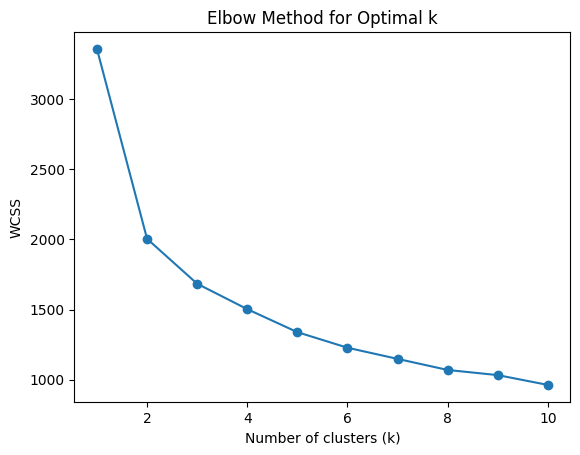

In [109]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()


In [110]:
df["SalaryClass"] = pd.qcut(
    df["Salary"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

df = df.dropna(subset=["SalaryClass"])


In [111]:
X = df.drop(columns=["Salary", "SalaryClass"])
y = df["SalaryClass"]


In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [114]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)



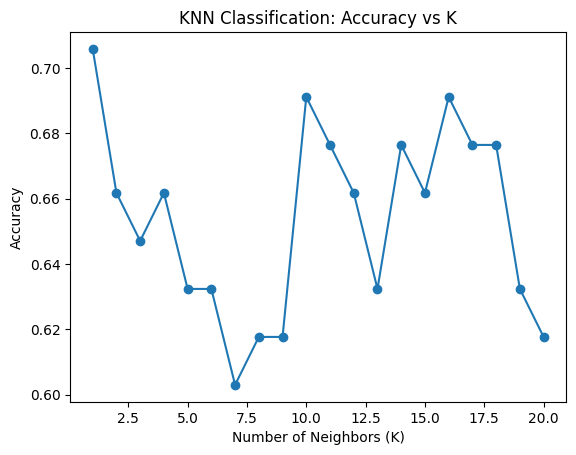

In [115]:
plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Classification: Accuracy vs K")
plt.show()


In [116]:
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# y_pred = knn.predict(X_test_scaled)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
